In [1]:

import os
import glob
import mne
import numpy as np
from mne.preprocessing import ica
from pathlib import Path

In [2]:
mne.set_log_level('WARNING')

# Claude V2:


In [19]:
def preprocess_raw(raw, notch_freq=50., l_freq=1., h_freq=64., 
                   montage_name='GSN-HydroCel-129', 
                   remove_ecg=False, remove_muscle=True):
    
    # Electrodes to discard AFTER artifact removal (not analysis-worthy)
    final_discard = ['E17', 'E38', 'E94', 'E113',
                      'E119', 'E121', 'E125', 
                      'E128', 'E73', 'E81', 'E88', 'E43', 'E44', 'E120', 'E114','E127', 'E126']
    
    # Keep these temporarily for artifact detection, remove later
    artifact_helper_chs = {
        'eog_horizontal': ['E1', 'E32'],      # Outer eye corners
        'eog_vertical': ['E14', 'E21'] ,     # Above/below eyes (already using)
       # 'muscle_temporal': ['E43', 'E44', 'E120', 'E114'],  # Jaw/temporal
        'muscle_neck': ['E56', 'E63', 'E107','E99']  # Neck/posterior
    }
    
    # Flatten all artifact helper channels
    keep_for_artifacts = []
    for ch_list in artifact_helper_chs.values():
        keep_for_artifacts.extend(ch_list)
    
    # Drop reference if exists
    if 'VREF' in raw.ch_names:
        raw.drop_channels('VREF')

    drop = raw.ch_names[-25:-2]
    raw.drop_channels(drop)
    
    # Only drop the final discard list (NOT artifact helpers yet)
    raw.drop_channels([ch for ch in final_discard if ch in raw.ch_names])
    print("afterr drop",len(raw.ch_names))
    print(f"{len([ch for ch in final_discard if ch in raw.ch_names])} non-informative electrodes")
    print(f"🎯 Kept {len([ch for ch in keep_for_artifacts if ch in raw.ch_names])} peripheral electrodes for artifact detection")

    # Set montage
    try:
        mont = mne.channels.make_standard_montage(montage_name)
        raw.set_montage(mont, match_case=False)
    except Exception:
        pass

    # Filter with padding
    raw.notch_filter(freqs=notch_freq, picks='eeg', verbose=False, pad='edge')
    raw.filter(l_freq=l_freq, h_freq=h_freq, picks='eeg', verbose=False, pad='edge')

    # Create EOG proxy (vertical eye movements)
    eog_vert = [ch for ch in artifact_helper_chs['eog_vertical'] if ch in raw.ch_names]
    if eog_vert:
        proxy_vert = raw.copy().pick_channels(eog_vert).get_data().mean(axis=0)
        info_vert = mne.create_info(['EOG_vertical'], raw.info['sfreq'], ch_types=['eog'])
        raw.add_channels([mne.io.RawArray(proxy_vert[None, :], info_vert)], force_update_info=True)
    
    # Create EOG proxy (horizontal eye movements)
    eog_horiz = [ch for ch in artifact_helper_chs['eog_horizontal'] if ch in raw.ch_names]
    if eog_horiz:
        proxy_horiz = raw.copy().pick_channels(eog_horiz).get_data().mean(axis=0)
        info_horiz = mne.create_info(['EOG_horizontal'], raw.info['sfreq'], ch_types=['eog'])
        raw.add_channels([mne.io.RawArray(proxy_horiz[None, :], info_horiz)], force_update_info=True)

    # ICA setup - fit on EEG channels only (not the proxies)
    eeg_raw = raw.copy().pick_types(eeg=True)
    rank = mne.compute_rank(eeg_raw, tol=1e-6, tol_kind='relative')
    n_components = min(25, rank['eeg'])
    
    print(f"\n🔧 Fitting ICA with {n_components} components on {len(eeg_raw.ch_names)} EEG channels...")
    ica = mne.preprocessing.ICA(n_components=n_components, random_state=42, 
                                method='fastica', max_iter=500)
    ica.fit(eeg_raw)
    
    # Find different artifact types
    bad_components = []
    
    # 1. EOG - vertical (blinks)
    if 'EOG_vertical' in raw.ch_names:
        eog_vert_idx, eog_vert_scores = ica.find_bads_eog(raw, ch_name='EOG_vertical', threshold=1.5)
        print(f"  Vertical EOG (blinks): {eog_vert_idx}")
        bad_components.extend(eog_vert_idx)
    
    # 2. EOG - horizontal (saccades)
    if 'EOG_horizontal' in raw.ch_names:
        eog_horiz_idx, eog_horiz_scores = ica.find_bads_eog(raw, ch_name='EOG_horizontal', threshold=1.5)
        print(f"  Horizontal EOG (saccades): {eog_horiz_idx}")
        bad_components.extend(eog_horiz_idx)

    
    # 4. Muscle artifacts
    if remove_muscle:
        try:
            # find_bads_muscle looks at high-frequency content across all channels
            muscle_indices, muscle_scores = ica.find_bads_muscle(raw, threshold=0.2)
            print(f" Muscle artifacts: {muscle_indices}")
            bad_components.extend(muscle_indices)
        except Exception as e:
            print(f"  Could not detect muscle: {e}")
    
    # Remove duplicates and apply
    ica.exclude = sorted(list(set(bad_components)))
    n_excluded = len(ica.exclude)
    print(f"\n Excluding {n_excluded}/{n_components} components ({n_excluded/n_components*100:.1f}%): {ica.exclude}")
    
    # Apply ICA
    raw = ica.apply(raw.copy())
    
    # NOW remove the artifact helper channels (no longer needed)
    raw.drop_channels([ch for ch in final_discard if ch in raw.ch_names])
    print(ch for ch in final_discard if ch in raw.ch_names)
    print(f"{len([ch for ch in final_discard if ch in raw.ch_names])} non-informative electrodes")
    channels_to_remove = [ch for ch in keep_for_artifacts if ch in raw.ch_names]
    channels_to_remove.extend(['EOG_vertical', 'EOG_horizontal'])  # Remove proxies too
    raw.drop_channels([ch for ch in channels_to_remove if ch in raw.ch_names])
    
    print(f" Removed {len(channels_to_remove)} artifact detection channels")
    print(f" Final channel count: {len(raw.ch_names)} (clean EEG only)")

    return raw, ica

In [20]:
# import mne
# import numpy as np

# def preprocess_raw(
#     raw,
#     notch_freq=50.,
#     l_freq=1.,
#     h_freq=64.,
#     montage_name='GSN-HydroCel-129',
#     n_components=20
# ):
#     """
#     Preprocess already loaded Raw object (EGI Hydrocel 128) with ICA artifact removal.
#     """

#     # --- Hardcoded lists ---
#     discard_channels = [
#         "E1", "E17", "E32", "E38", "E43", "E44",
#         "E48", "E49", "E56", "E63", "E68", "E73",
#         "E81", "E88", "E94", "E99", "E107", "E113",
#         "E119", "E120", "E125", "E126", "E127", "E128"
#     ]

#     eog_mapping = {
#         'HEOG': ['E25', 'E128'],
#         'VEOG': ['E8', 'E126']
#     }

#     ref_channels = ['Cz']

#     # --- Drop event marker channels ---
#     eeg_chs = [ch for ch in raw.ch_names if 'E' in ch and ch[1:].isdigit()]
#     raw.pick_channels(eeg_chs, ordered=True)

#     # --- Drop bad channels ---
#     existing_discards = [ch for ch in discard_channels if ch in raw.ch_names]
#     raw.drop_channels(existing_discards)

#     # --- Set montage ---
#     montage = mne.channels.make_standard_montage(montage_name)
#     raw.set_montage(montage, on_missing='ignore')

#     # --- Add EOG channels ---
#     eog_data = []
#     for eog_name, pair in eog_mapping.items():
#         valid = [ch for ch in pair if ch in raw.ch_names]
#         if len(valid) == 2:
#             sig = raw.get_data(valid[0]) - raw.get_data(valid[1])
#             info = mne.create_info([eog_name], raw.info['sfreq'], ['eog'])
#             eog_raw = mne.io.RawArray(sig, info)
#             eog_data.append(eog_raw)
#     if eog_data:
#         raw.add_channels(eog_data)

#     # --- Filtering ---
#     raw.notch_filter(notch_freq)
#     raw.filter(l_freq, h_freq, fir_design='firwin')

#     # --- Re-reference ---
#     raw.set_eeg_reference(ref_channels=ref_channels)

#     # --- ICA artifact removal ---
#     ica = mne.preprocessing.ICA(
#         n_components=n_components,
#         method='fastica',
#         random_state=42,
#         max_iter='auto'
#     )
#     ica.fit(raw)

#     # Detect EOG-related ICs
#     eog_inds, _ = ica.find_bads_eog(raw, threshold=2.0)
#     ica.exclude = eog_inds
#     raw_clean = ica.apply(raw.copy())

#     # --- Final consistent selection ---
#     raw_clean.pick_types(eeg=True, eog=True)
#     raw_clean.reorder_channels(sorted(raw_clean.ch_names))

#     return raw_clean, ica


afterr drop 113
0 non-informative electrodes
🎯 Kept 8 peripheral electrodes for artifact detection

🔧 Fitting ICA with 25 components on 111 EEG channels...
  Vertical EOG (blinks): [np.int64(0), np.int64(1), np.int64(15)]
  Horizontal EOG (saccades): [np.int64(0), np.int64(15), np.int64(19)]
 Muscle artifacts: [2, 3, 22]

 Excluding 7/25 components (28.0%): [np.int64(0), np.int64(1), 2, 3, np.int64(15), np.int64(19), 22]
<generator object preprocess_raw.<locals>.<genexpr> at 0x130b0fb90>
0 non-informative electrodes
 Removed 10 artifact detection channels
 Final channel count: 105 (clean EEG only)
Channels after cleaning: 105


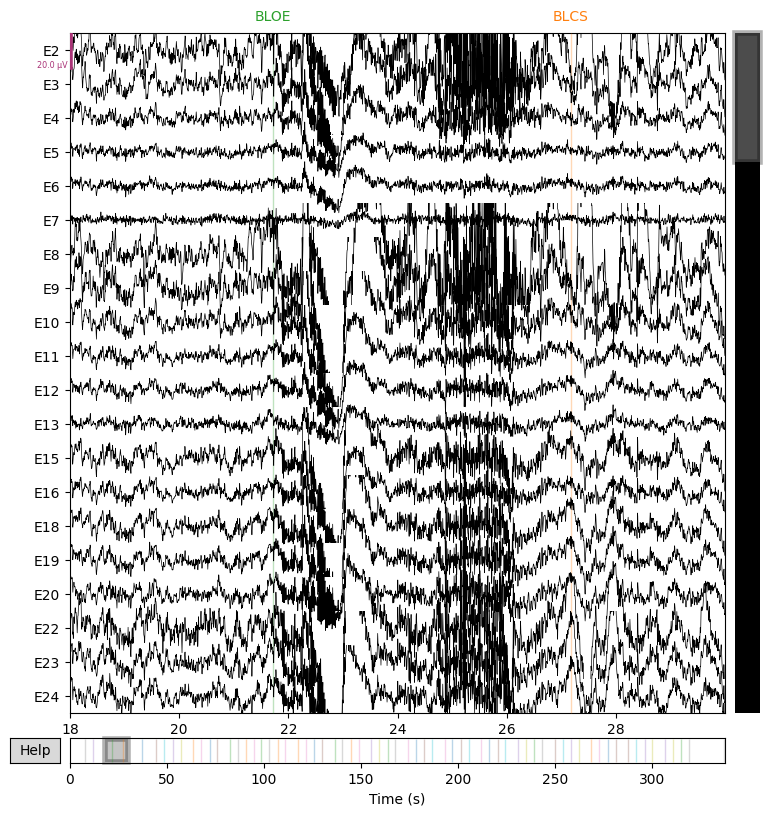

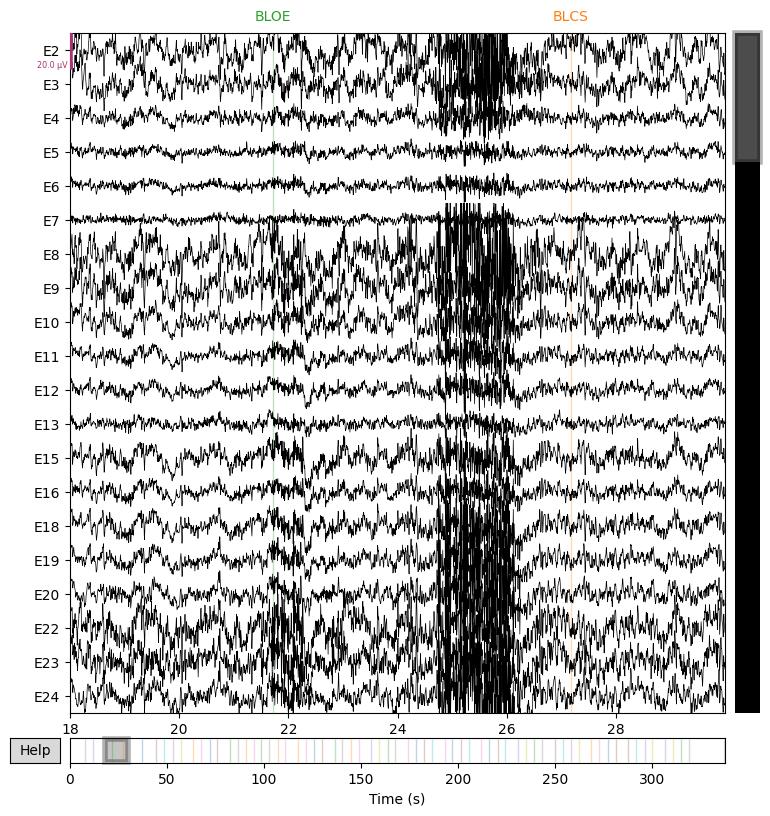

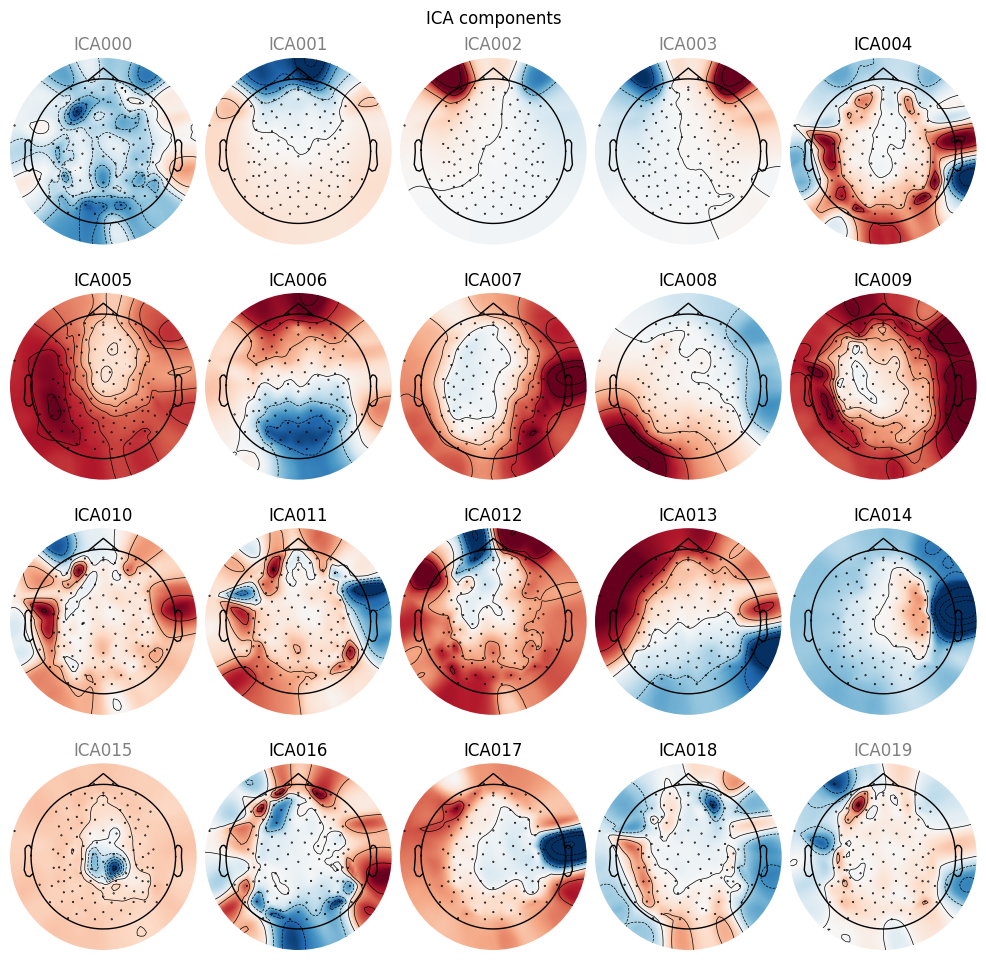

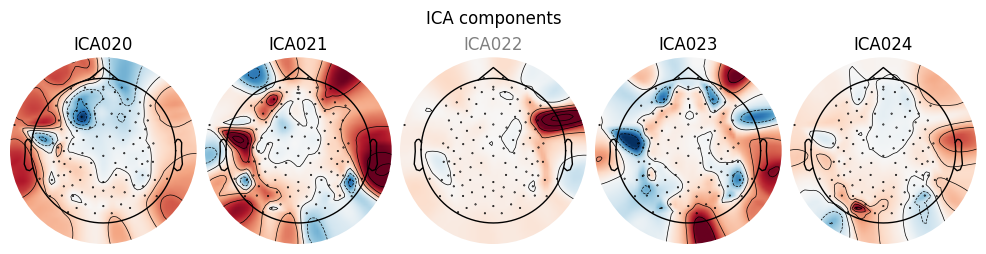

Excluded components: [np.int64(0), np.int64(1), 2, 3, np.int64(15), np.int64(19), 22]


In [21]:



# --- Import preprocess function ---


# --- Path to one EEG recording ---
test_file = Path("/Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/Data/S115/VI_S5_S1_B2__20251114_040445.mff")  # or .raw/.fif

# --- Load and run preprocessing ---
raw = mne.io.read_raw_egi(test_file, preload=True)
raw_clean, ica = preprocess_raw(raw)
common_chs = [ch for ch in raw.ch_names if ch in raw_clean.ch_names]
cm_chs = ['E11','E12','E19','E4','E124']

# --- Check channel info ---
print(f"Channels after cleaning: {len(raw_clean.ch_names)}")
scaling = dict(eeg=10e-6)  # more zoomed-in
raw.plot(title="Before ICA (original)", start = 18 ,picks = common_chs, scalings=scaling, duration=12, block=True)


raw_clean.plot(title="After ICA (cleaned)", start = 18,picks = common_chs, scalings=scaling, duration=12, block=True)


# --- Plot ICA diagnostics ---
ica.plot_components()
#ica.plot_scores(ica.score_sources(raw_clean, target='EOG_proxy'))
#ica.plot_sources(raw_clean)

# --- Optional: verify excluded components ---
print("Excluded components:", ica.exclude)


In [34]:
drop = raw.ch_names[-25:-2]

In [ ]:
drop = raw.ch_names[-25:-2]
raw.drop_channels(drop)

<RawMff | signal1.bin, 113 x 160793 (321.6 s), ~138.8 MiB, data loaded>

In [6]:
len(raw_clean.ch_names)

130

In [ ]:

import os
import glob
import mne
import numpy as np
from mne.preprocessing import ica
def read_any_raw(path):
    ext = os.path.splitext(path)[1].lower()
    if ext in ('.raw', '.mff'):
        return mne.io.read_raw_egi(path, preload=True)


def preprocess_raw(raw, notch_freq=50., l_freq=1., h_freq=64., 
                   montage_name='GSN-HydroCel-129', 
                   remove_ecg=True, remove_muscle=True):
    
    # Electrodes to discard AFTER artifact removal (not analysis-worthy)
    final_discard = ["E17", "E38", "E94", "E99", "E107", "E113",
                     "E114", "E119", "E120", "E121", "E125", "E126", 
                     "E127", "E128", "E73", "E81", "E88"]
    
    # Keep these temporarily for artifact detection, remove later
    artifact_helper_chs = {
        'eog_horizontal': ['E1', 'E32'],      # Outer eye corners
        'eog_vertical': ['E14', 'E21'],       # Above/below eyes (already using)
        'muscle_temporal': ['E43', 'E44', 'E48', 'E49'],  # Jaw/temporal
        'muscle_neck': ['E56', 'E63', 'E68']  # Neck/posterior
    }
    
    # Flatten all artifact helper channels
    keep_for_artifacts = []
    for ch_list in artifact_helper_chs.values():
        keep_for_artifacts.extend(ch_list)
    
    # Drop reference if exists
    if 'VREF' in raw.ch_names:
        raw.drop_channels('VREF')

    # Only drop the final discard list (NOT artifact helpers yet)
    raw.drop_channels([ch for ch in final_discard if ch in raw.ch_names])
    print(f"🗑️  Dropped {len([ch for ch in final_discard if ch in raw.ch_names])} non-informative electrodes")
    print(f"🎯 Kept {len([ch for ch in keep_for_artifacts if ch in raw.ch_names])} peripheral electrodes for artifact detection")

    # Set montage
    try:
        mont = mne.channels.make_standard_montage(montage_name)
        raw.set_montage(mont, match_case=False)
    except Exception:
        pass

    # Filter with padding
    raw.notch_filter(freqs=notch_freq, picks='eeg', verbose=False, pad='edge')
    raw.filter(l_freq=l_freq, h_freq=h_freq, picks='eeg', verbose=False, pad='edge')

    # Create EOG proxy (vertical eye movements)
    eog_vert = [ch for ch in artifact_helper_chs['eog_vertical'] if ch in raw.ch_names]
    if eog_vert:
        proxy_vert = raw.copy().pick_channels(eog_vert).get_data().mean(axis=0)
        info_vert = mne.create_info(['EOG_vertical'], raw.info['sfreq'], ch_types=['eog'])
        raw.add_channels([mne.io.RawArray(proxy_vert[None, :], info_vert)], force_update_info=True)
    
    # Create EOG proxy (horizontal eye movements)
    eog_horiz = [ch for ch in artifact_helper_chs['eog_horizontal'] if ch in raw.ch_names]
    if eog_horiz:
        proxy_horiz = raw.copy().pick_channels(eog_horiz).get_data().mean(axis=0)
        info_horiz = mne.create_info(['EOG_horizontal'], raw.info['sfreq'], ch_types=['eog'])
        raw.add_channels([mne.io.RawArray(proxy_horiz[None, :], info_horiz)], force_update_info=True)

    # ICA setup - fit on EEG channels only (not the proxies)
    eeg_raw = raw.copy().pick_types(eeg=True)
    rank = mne.compute_rank(eeg_raw, tol=1e-6, tol_kind='relative')
    n_components = min(25, rank['eeg'])
    
    print(f"\n🔧 Fitting ICA with {n_components} components on {len(eeg_raw.ch_names)} EEG channels...")
    ica = mne.preprocessing.ICA(n_components=n_components, random_state=42, 
                                method='fastica', max_iter=500)
    ica.fit(eeg_raw)
    
    # Find different artifact types
    bad_components = []
    
    # 1. EOG - vertical (blinks)
    if 'EOG_vertical' in raw.ch_names:
        eog_vert_idx, eog_vert_scores = ica.find_bads_eog(raw, ch_name='EOG_vertical', threshold=2.5)
        print(f"  Vertical EOG (blinks): {eog_vert_idx}")
        bad_components.extend(eog_vert_idx)
    
    # 2. EOG - horizontal (saccades)
    if 'EOG_horizontal' in raw.ch_names:
        eog_horiz_idx, eog_horiz_scores = ica.find_bads_eog(raw, ch_name='EOG_horizontal', threshold=2.5)
        print(f"  Horizontal EOG (saccades): {eog_horiz_idx}")
        bad_components.extend(eog_horiz_idx)
    
    # 3. ECG (heartbeat)
    if remove_ecg:
        try:
            ecg_indices, ecg_scores = ica.find_bads_ecg(raw, method='correlation', threshold='auto')
            print(f"  ECG (heartbeat): {ecg_indices}")
            bad_components.extend(ecg_indices)
        except Exception as e:
            print(f"  Could not detect ECG: {e}")
    
    # 4. Muscle artifacts
    if remove_muscle:
        try:
            # find_bads_muscle looks at high-frequency content across all channels
            muscle_indices, muscle_scores = ica.find_bads_muscle(raw, threshold=0.5)
            print(f" Muscle artifacts: {muscle_indices}")
            bad_components.extend(muscle_indices)
        except Exception as e:
            print(f"  Could not detect muscle: {e}")
    
    # Remove duplicates and apply
    ica.exclude = sorted(list(set(bad_components)))
    n_excluded = len(ica.exclude)
    print(f"\n Excluding {n_excluded}/{n_components} components ({n_excluded/n_components*100:.1f}%): {ica.exclude}")
    
    # Apply ICA
    raw = ica.apply(raw.copy())
    
    # NOW remove the artifact helper channels (no longer needed)
    channels_to_remove = [ch for ch in keep_for_artifacts if ch in raw.ch_names]
    channels_to_remove.extend(['EOG_vertical', 'EOG_horizontal'])  # Remove proxies too
    raw.drop_channels([ch for ch in channels_to_remove if ch in raw.ch_names])
    
    print(f" Removed {len(channels_to_remove)} artifact detection channels")
    print(f" Final channel count: {len(raw.ch_names)} (clean EEG only)")

    return raw, ica


def extract_start_event_ids(event_id_map):
    # select annotation keys that mark START of Observation/Imagination (OS*, IS*)
    return {k: v for k, v in event_id_map.items() if k.startswith('OS') or k.startswith('IS')}
def epoch_recording(path, out_dir, tmin=0.0, tmax=4.0, reject=None):
    raw = read_any_raw(path)
    raw.pick_types(eeg=True)

    raw_clean, ica = preprocess_raw(raw)

    if raw_clean.info["bads"]:
        raw.drop_channels(raw.info["bads"])
        print(f"Dropped {len(raw_clean.info['bads'])} bad channels: {raw_clean.info['bads']}")

    # --- Define fixed canonical mapping for all recordings ---
    CANONICAL_EVENT_ID = {
        'ISBA': 0, 'ISBY': 1, 'ISDO': 2, 'ISMO': 3, 'ISSI': 4,
        'OSBA': 10, 'OSBY': 11, 'OSDO': 12, 'OSMO': 13, 'OSSI': 14,
    }

    # --- Manually extract canonical events from annotations ---
    annots = raw.annotations
    events_list = []
    for a in annots:
        desc = a['description'].strip().upper()
        if desc in CANONICAL_EVENT_ID:
            sample = int(a['onset'] * raw.info['sfreq'])
            events_list.append([sample, 0, CANONICAL_EVENT_ID[desc]])

    if not events_list:
        print(f"No canonical events found in {os.path.basename(path)}")
        return None

    events = np.array(events_list, dtype=int)
    event_id = CANONICAL_EVENT_ID
    sel_event_id = extract_start_event_ids(event_id)

    # --- Align relative to baseline END (BSEN) ---
    bs_end = [a['onset'] for a in annots if 'BSEN' in a['description'].upper()]
    if bs_end:
        offset = bs_end[0]
        events[:, 0] -= int(offset * raw_clean.info['sfreq'])
        print(f"⏱️ Re-aligned events in {os.path.basename(path)} by {-offset:.2f}s (BSEN)")

    # --- Create epochs ---
    epochs = mne.Epochs(
        raw_clean, events, event_id=sel_event_id,
        tmin=tmin, tmax=tmax,
        baseline=None, preload=True, reject=reject, verbose=False
    )

    out_path = os.path.join(out_dir, f"{os.path.splitext(os.path.basename(path))[0]}-epo.fif")
    os.makedirs(out_dir, exist_ok=True)
    epochs.save(out_path, overwrite=True)
    return epochs



# Run over Data folder: assumes structure Data/<subject>/*.raw|*.mff|*.edf|*.fif
DATA_DIR = "/Users/kavinfidel/Documents/Fidel/CNS_Lab/VM_EEG/Data"
OUT_DIR = "/Users/kavinfidel/Documents/Fidel/CNS_Lab/VM_EEG/epochs_ica"

for subj_dir in sorted(glob.glob(os.path.join(DATA_DIR, "*"))):
    if not os.path.isdir(subj_dir): 
        continue
    rec_files = []
    for ext in ('*.raw','*.mff','*.edf','*.fif','*.edf.gz','*.raw.gz'):
        rec_files.extend(glob.glob(os.path.join(subj_dir, ext)))
    for rec in sorted(rec_files):
        try:
            epoch_recording(rec, out_dir=os.path.join(OUT_DIR, os.path.basename(subj_dir)))
        except Exception as e:
            print(f"Error processing {rec}: {e}")


In [ ]:
import glob, os, mne, numpy as np

In [ ]:

mne.set_log_level('ERROR') 
EPOCHS_DIR = "/Users/kavinfidel/Documents/Fidel/CNS_Lab/VM_EEG/epochs_ica"

# Step 1: Load reference channel set from one clean subject (e.g., S1)
ref_path = glob.glob(os.path.join(EPOCHS_DIR, "S1", "*-epo.fif"))[0]
ref_epochs = mne.read_epochs(ref_path, preload=False)
ref_chs = set(ref_epochs.ch_names)

epochs_all, labels_all = [], []

# Step 2: Iterate through all subjects
for subj_dir in sorted(glob.glob(os.path.join(EPOCHS_DIR, "S*"))):
    for recording in sorted(glob.glob(os.path.join(subj_dir, "*-epo.fif"))):
        epo_files = recording
       # print("channels",len(epo_files.ch_names))
        if not epo_files:
            continue
        epochs = mne.read_epochs(epo_files, preload=True,verbose = False)

        # Keep only reference EEG channels
        common_chs = [ch for ch in epochs.ch_names if ch in ref_chs]
        epochs.pick(common_chs)

        X = epochs.get_data()  # (n_epochs, n_channels, n_times)
        print(epochs.event_id)
        y = epochs.events[:, -1]
        epochs_all.append(X)
        labels_all.append(y)
        print(f"{os.path.basename(subj_dir)} -> {X.shape}")

# Step 3: Combine all
print(len(epochs_all))
print(len(labels_all))
print(f"epochs_all: {epochs_all}")
X = np.concatenate(epochs_all, axis=0)
y = np.concatenate(labels_all, axis=0)
print("✅ Combined shape:", X.shape, y.shape)


In [ ]:
X_reshaped = X.transpose(0, 2, 1)


In [ ]:
X_reshaped.shape

In [ ]:
# imagination and observation label groups
imagination_codes = [0,1,2,3,4]
observation_codes = [10, 11, 12, 13, 14]

# Boolean masks
mask_imag = np.isin(y, imagination_codes)
mask_obs = np.isin(y, observation_codes)

# Separate datasets
X_imag, y_imag = X_reshaped[mask_imag], y[mask_imag]
X_obs, y_obs = X_reshaped[mask_obs], y[mask_obs]



* 0 : Banana
* 1 : Baby
* 2 : Dog
* 3 : Monkey
* 4 : Sitar

In [ ]:
X_imag.shape

In [ ]:
y_imag.shape

In [ ]:
SAVE_DIR = "/Users/kavinfidel/Documents/Fidel/CNS_Lab/VM_EEG/processed_ica"
os.makedirs(SAVE_DIR, exist_ok=True)

# assume these are your arrays
# X = np array of shape (480, 128, 2001)
# y = np array of shape (480,)

np.save(os.path.join(SAVE_DIR, "X_imag.npy"), X_imag)
np.save(os.path.join(SAVE_DIR, "y_imag.npy"), y_imag)

print("✅ Saved EEG data successfully!")

In [ ]:
np.save(os.path.join(SAVE_DIR, "X_obs.npy"), X_obs)
np.save(os.path.join(SAVE_DIR, "y_obs.npy"), y_obs)

print("✅ Saved EEG data successfully!")

In [4]:
X_imag =  np.load("/Users/kavinfidel/Documents/Fidel/CNS_Lab/VM_EEG/processed_ica/X_imag.npy")
y_imag = np.load("/Users/kavinfidel/Documents/Fidel/CNS_Lab/VM_EEG/processed_ica/y_imag.npy")

In [5]:
X_imag.shape

(285, 2001, 100)

In [ ]:
chunk_size = 667   # roughly 2001 / 3 → ~1.33s chunks
n_chunks = X_imag.shape[1] // chunk_size  # ← Changed from shape[-1] to shape[1]

print(f"DEBUG: X_imag shape: {X_imag.shape}")
print(f"DEBUG: Time points: {X_imag.shape[1]}, chunk_size: {chunk_size}, n_chunks: {n_chunks}")

# Non-overlapping chunking
X_imag_chunked = []
y_imag_chunked = []

for i in range(X_imag.shape[0]):
    for j in range(n_chunks):
        start = j * chunk_size
        end = start + chunk_size
        X_imag_chunked.append(X_imag[i, start:end, :])  # ← Slice the time dimension (axis 1)
        y_imag_chunked.append(y_imag[i])

X_imag_chunked = np.array(X_imag_chunked)
y_imag_chunked = np.array(y_imag_chunked)

print(f"✅ Chunked: {X_imag.shape[0]} → {X_imag_chunked.shape[0]} samples, each {chunk_size/X_imag.shape[1]*4:.2f}s long")
print(f"New shapes: X {X_imag_chunked.shape}, y {y_imag_chunked.shape}")

In [ ]:
os.makedirs("/Users/kavinfidel/Documents/Fidel/CNS_Lab/VM_EEG/processed_ica/chunked_numpy", exist_ok=True)
np.save("/Users/kavinfidel/Documents/Fidel/CNS_Lab/VM_EEG/processed_ica/chunked_numpy/X_chunked_img.npy", X_imag_chunked)
np.save("/Users/kavinfidel/Documents/Fidel/CNS_Lab/VM_EEG/processed_ica/chunked_numpy/y_chunked_img.npy", y_imag_chunked)

In [ ]:
7872/64

In [ ]:
64*4